In [36]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from scipy import stats
import utils
import seaborn as sns
import pingouin as pg
import matplotlib.cm as cm

import statsmodels.stats.power as smp
from statsmodels.stats.anova import AnovaRM
from tqdm import tqdm

# reload utils
import importlib
importlib.reload(utils)


from natsort import index_natsorted

# plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams['font.family'] = 'Calibri'

path_figs = "./Figs/"

seq_length = 7 #Length of sequences

windowSizes = [1, 2, 3, 7]

fingers = ['1', '2', '3', '4', '5'] #mapping of fingers to numbers

iti = 3000   #Inter trial interval
hand = 2 #left or right hand

# total_sub_num = 10
sub_nums = [1,2,3, 4, 5, 6, 7, 8, 9, 10]

num_trained_seq = 1

total_sub_num = 20
num_sessions = 3
num_blocks_per_session = 4

num_baseline_blocks = 1
num_trials_per_block = 40

percentile_low = 45;	# Lower percentile for ETs
percentile_high = 80;	# Upper percentile for ETs
percentile_low_super = 10;	# Lower percentile for ETs



In [37]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker

def set_figure_style(scale="1col"):
    """
    Set figure styling based on publication constraints.
    
    Parameters:
        scale (str): Scale of the figure, choose from "1col", "1.5col", "2col".
                     - "1col" for 8.5cm
                     - "1.5col" for 11.6cm
                     - "2col" for 17.6cm
    """
    # Define width options in cm
    widths = {"1col": 7.62, "1.5col": 11.6, "2col": 16.5}
    
    if scale not in widths:
        raise ValueError("Invalid scale. Choose from '1col', '1.5col', or '2col'.")
    
    # Convert width from cm to inches (1 cm = 0.393701 inches)
    width_in = widths[scale] * 0.393701
    
    # Set figure size (width, height)
    # Assuming height proportional to width (Golden Ratio)
    golden_ratio = (5**0.5 - 1) / 2
    rcParams["figure.figsize"] = (width_in, width_in * golden_ratio)
    
    # Set font sizes
    rcParams["font.size"] = 10  # General font size
    # rcParams["font.size"] = 20  # General font size
    rcParams["axes.titlesize"] = 12  # Figure title
    # rcParams["axes.titlesize"] = 26  # Figure title
    rcParams["axes.labelsize"] = 9  # Axis main label
    # rcParams["axes.labelsize"] = 22  # Axis main label
    rcParams["xtick.labelsize"] = 7  # Tick labels
    # rcParams["xtick.labelsize"] = 16  # Tick labels
    rcParams["ytick.labelsize"] = 7
    # rcParams["ytick.labelsize"] = 16
    rcParams["legend.fontsize"] = 8  # Legend entries
    # rcParams["legend.fontsize"] = 20  # Legend entries
    rcParams["figure.titleweight"] = "bold"
    
    # Set stroke width
    rcParams["axes.linewidth"] = 0.75
    # rcParams["axes.linewidth"] = 1.5

    # rcParams["lines.linewidth"] = 3
    
    rcParams["xtick.major.width"] = 0.75
    # rcParams["xtick.major.width"] = 1.5
    rcParams["ytick.major.width"] = 0.75
    # rcParams["ytick.major.width"] = 1.5

    
    # Subpanel lettering size
    rcParams["text.usetex"] = False  # Set to True if using LaTeX
    rcParams["axes.formatter.use_mathtext"] = True  # Math text for scientific notation

def add_subpanel_label(ax, label, fontsize=20, position=(-0.1, 1.05)):
    """
    Add a subpanel label (e.g., 'a', 'b') to a subplot.
    
    Parameters:
        ax (Axes): Matplotlib Axes object.
        label (str): The label text.
        fontsize (int): Font size for the label.
        position (tuple): Position of the label in axes coordinates.
    """
    ax.text(position[0], position[1], label, transform=ax.transAxes, 
            fontsize=fontsize, fontweight="bold", va="top", ha="left")

###
set_figure_style(scale="1col")

sns.set_palette("colorblind")


In [38]:
subjs = pd.read_csv(utils.path_misc+'subjs.csv', sep = '\t')

# exclude first block 
subjs = subjs[subjs['BN'] > 1]
rank_df = pd.DataFrame(index = subjs.index)
for subnum, data in subjs.groupby('SubNum'):
    data = data.sort_values(by = ['BN', 'TN'])
    data['N'] = data.groupby(['BN', 'TN']).ngroup() + 1
    rank_df.loc[data.index, 'N'] = data['N'].astype('int')
        

subjs['N'] = rank_df['N'].astype('int')
subjs = subjs[subjs['isCross'] == 0]

# adding day column to subjs
day1_blocks =list(range(2, num_blocks_per_session + 2))  # Blocks 2 to 5
day2_blocks = list(range(num_blocks_per_session + 2, num_blocks_per_session * 2 + 2))  # Blocks 6 to 9
day3_blocks = list(range(num_blocks_per_session * 2 + 2, num_blocks_per_session * 3 + 2))  # Blocks 10 to 13
day4_blocks = list(range(num_blocks_per_session * 3 + 2, num_blocks_per_session * 4 + 2))  # Blocks 14 to 17


In [39]:
subjs['day'] = 0
subjs.loc[subjs['BN'].isin(day1_blocks), 'day'] = 1
subjs.loc[subjs['BN'].isin(day2_blocks), 'day'] = 2
subjs.loc[subjs['BN'].isin(day3_blocks), 'day'] = 3
subjs.loc[subjs['BN'].isin(day4_blocks), 'day'] = 4


In [40]:
# adding day change column to the subjs dataframe
subjs['day_change'] = 0
subjs.loc[subjs['day'] != subjs['day'].shift(1), 'day_change'] = 1

# adding block change column to the processed_forces dataframe
subjs['block_change'] = 0
subjs.loc[subjs['BN'] != subjs['BN'].shift(1), 'block_change'] = 1


In [41]:
subjs

,BN,TN,SubNum,hand,isTrain,cue,press1,press2,press3,press4,...,IPI1,IPI2,IPI3,IPI4,IPI5,IPI6,N,day,day_change,block_change
40,2,1,1,2,1,1214532,1,2,1,4,...,120,250,460,365,505,330,1,1,1,1
41,2,2,1,2,1,1214532,1,2,1,4,...,135,200,420,320,630,305,2,1,0,0
42,2,3,1,2,1,1214532,1,2,1,4,...,130,195,430,355,415,325,3,1,0,0
43,2,4,1,2,1,1214532,1,2,1,4,...,130,270,450,250,495,255,4,1,0,0
44,2,5,1,2,1,1214532,1,2,1,4,...,115,205,765,285,515,290,5,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6794,17,35,10,2,1,3512434,3,5,1,2,...,275,430,620,455,200,175,635,4,0,0
6795,17,36,10,2,1,3512434,3,5,1,2,...,275,375,190,485,360,205,636,4,0,0
6797,17,38,10,2,1,3512434,3,5,1,2,...,290,345,215,495,335,215,638,4,0,0
6798,17,39,10,2,1,3512434,3,5,1,2,...,345,555,615,375,265,235,639,4,0,0


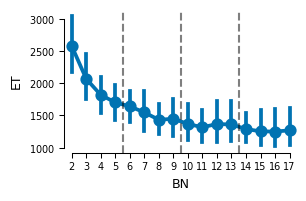

In [33]:
subjs_correct = utils.remove_error_trials(subjs) ###Removing error trials
# subjs_correct = subjs.copy()
subjs_grouped = subjs_correct.groupby(['SubNum', 'BN']).agg({
    'ET': 'median'
}).reset_index()
sns.pointplot(data = subjs_grouped, x = 'BN', y = 'ET')
for day_change in [3.5, 7.5, 11.5]:
    plt.axvline(day_change, color = 'k', linestyle = '--', alpha = 0.5)
sns.despine(trim = True)


1
41
81
121
161
201
241
281
321
361
401
441
481
521
561
601


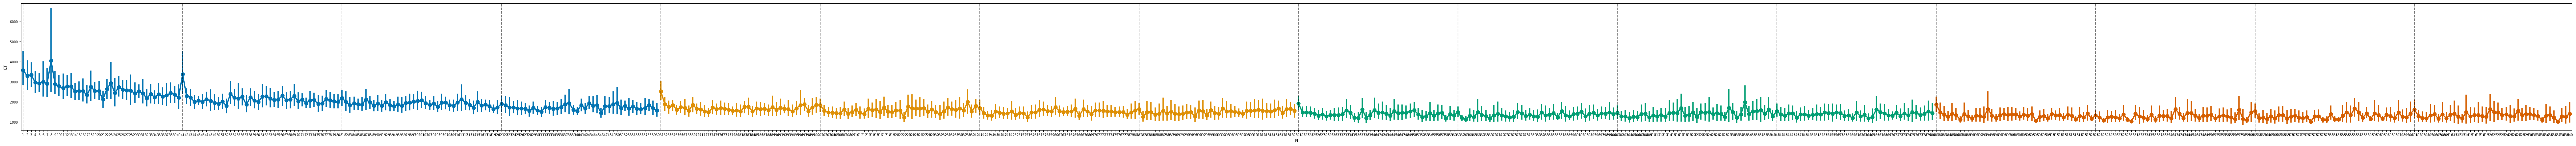

In [ ]:
plt.figure(figsize = (100, 5))
subjs_correct = utils.remove_error_trials(subjs) ###Removing error trials
# subjs_correct = subjs.copy()
subjs_grouped = subjs_correct.groupby(['SubNum', 'N', 'BN', 'day', 'block_change']).agg({
    'ET': 'median'
}).reset_index()

for day, day_data in subjs_grouped.groupby('day'):
    sns.pointplot(data = day_data, x = 'N', y = 'ET')

block_changes = subjs[subjs['block_change'] == 1]

for n in block_changes['N'].unique():
    plt.axvline(n - 1, color = 'k', linestyle = '--', alpha = 0.5)


# sns.pointplot(data = subjs_grouped, x = 'N', y = 'ET')


In [44]:
block_changes['N'].unique()

array([  1,  41,  81, 121, 161, 201, 241, 281, 321, 361, 401, 441, 481,
       521, 561, 601])

In [18]:
subjs_grouped

,SubNum,N,BN,day,ET
0,1,1,2,1,3025.0
1,1,2,2,1,2760.0
2,1,3,2,1,2610.0
3,1,4,2,1,2475.0
4,1,5,2,1,2795.0
...,...,...,...,...,...
5472,10,635,17,0,2680.0
5473,10,636,17,0,2430.0
5474,10,638,17,0,2525.0
5475,10,639,17,0,2945.0
